In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad

In [ ]:
# -------------------------------------
# 1) Taylor / Maclaurin polynomial up to N
# -------------------------------------
def taylor_maclaurin_coeffs(f, N: int, use_sympy: bool = True):
    """
    Returns coefficients [c0, c1, ..., cN] for sum_{k=0..N} c_k x^k
    """
    xs =
    coeffs = np.polyfit()

    # Fallback: numeric derivatives at 0
    for k in range(N + 1):
        d = finite_diff_derivative(f, 0.0, k)
        coeffs.append(d / math.factorial(k))
    return coeffs


def taylor_approx_function(coeffs):
    """
    Returns a callable p(x) evaluating the Taylor polynomial with given coeffs.
    coeffs[k] corresponds to x^k term.
    """
    coeffs = np.array(coeffs, dtype=float)

    def p(x):
        x_arr = np.asarray(x, dtype=float)
        # Horner evaluation
        y = np.zeros_like(x_arr, dtype=float)
        for c in coeffs[::-1]:
            y = y * x_arr + c
        return y

    return p

In [ ]:
# -------------------------------------
# 2) Fourier series coefficients on [-L, L]
#    f(x) ~ a0/2 + sum_{n=1..N} [a_n cos(n pi x / L) + b_n sin(n pi x / L)]
# -------------------------------------
def _quad_integrate(func, a, b):
    val, _err = quad(func, a, b, limit=200)
    return val

def _trapz_integrate(func, a, b, M=20000):
    xs = np.linspace(a, b, M, endpoint=True)
    ys = func(xs)
    return float(np.trapz(ys, xs))

def fourier_coeffs(f, L: float, N: int, method: str = "auto"):
    """
    Returns (a0, a, b) where:
      a0 is scalar
      a[n-1] is a_n for n=1..N
      b[n-1] is b_n for n=1..N
    """
    if L <= 0:
        raise ValueError("L must be positive.")
    if N < 0:
        raise ValueError("N must be >= 0.")

    w = math.pi / L

    if method == "auto":
        integrate = _quad_integrate if HAS_SCIPY else _trapz_integrate
    elif method == "quad":
        integrate = _quad_integrate
    elif method == "trapz":
        integrate = _trapz_integrate
    else:
        raise ValueError("method must be one of: auto, quad, trapz")

    # a0 = (1/L) ∫_{-L..L} f(x) dx
    a0 = (1.0 / L) * integrate(lambda t: f(t), -L, L)

    a = np.zeros(N, dtype=float)
    b = np.zeros(N, dtype=float)

    for n in range(1, N + 1):
        an = (1.0 / L) * integrate(lambda t, n=n: f(t) * math.cos(n * w * t), -L, L)
        bn = (1.0 / L) * integrate(lambda t, n=n: f(t) * math.sin(n * w * t), -L, L)
        a[n - 1] = an
        b[n - 1] = bn

    return float(a0), a, b


def fourier_approx_function(L: float, a0: float, a: np.ndarray, b: np.ndarray):
    """
    Returns a callable S_N(x) for the Fourier partial sum up to N harmonics.
    """
    N = len(a)
    w = math.pi / L

    def S(x):
        x_arr = np.asarray(x, dtype=float)
        s = 0.5 * a0 * np.ones_like(x_arr, dtype=float)
        for n in range(1, N + 1):
            s += a[n - 1] * np.cos(n * w * x_arr) + b[n - 1] * np.sin(n * w * x_arr)
        return s

    return S

$$f(x)=(1+x) e^{-x^3 \sin x}$$

In [114]:
# Numeric version used for integration/evaluation
def f_numpy(x: np.ndarray | float) -> np.ndarray | float:
    return (1+x) * np.exp(-x*x*x*np.sin(x))

In [115]:
L = 2
xs = np.linspace(-L, L, 100)

ys = f_numpy(xs)

n_poly = 13
poly = np.polyfit(xs, ys, n_poly)
y_fit = np.polyval(poly, xs)

poly = np.array([0 if abs(x) < 1e-10 else x for x in poly])

poly

array([-0.00545486, -0.00480799,  0.08216638,  0.07397265, -0.48383041,
       -0.44406218,  1.36174655,  1.2695132 , -1.66885357, -1.56542909,
        0.15624647,  0.10687518,  0.9900192 ,  0.99669593])

In [116]:
poly_rep = ""

for i, a in enumerate(poly[::-1]):
    if a != 0:
        poly_rep += f"{round(a, 3)}x^{i}+"

poly_rep

'0.997x^0+0.99x^1+0.107x^2+0.156x^3+-1.565x^4+-1.669x^5+1.27x^6+1.362x^7+-0.444x^8+-0.484x^9+0.074x^10+0.082x^11+-0.005x^12+-0.005x^13+'

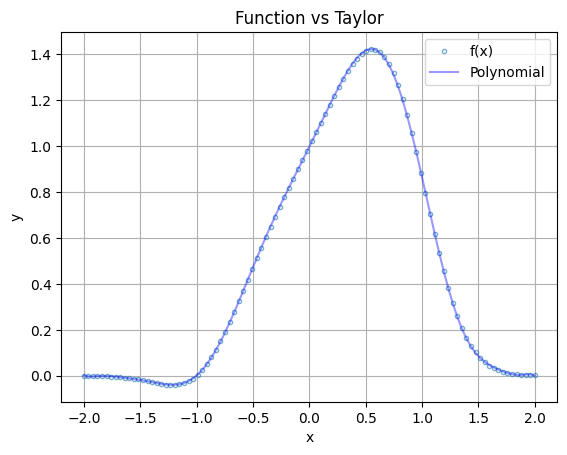

In [122]:
plt.figure()
plt.plot(xs, ys, linestyle='None', marker='o',markerfacecolor='none', markersize=3, label="f(x)", alpha=0.6)
plt.plot(xs, y_fit, 'b-', label="Polynomial", alpha=0.4)
plt.legend()
plt.title("Function vs Taylor")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(1)

plt.savefig("f_taylor_approx.svg", format="svg", bbox_inches="tight")

plt.show()

plt.close()

In [118]:
# Fourier
N = 4
a0, a, b = fourier_coeffs(lambda t: float(f_numpy(t)), L, N, method="auto")
SN = fourier_approx_function(L, a0, a, b)

In [119]:
sx = SN(xs)

In [120]:
print("\nFourier coefficients:")
print(f"  a0 = {a0:.12g}")
for n in range(1, min(6, N + 1)):
    print(f"  a_{n} = {a[n-1]:.12g},  b_{n} = {b[n-1]:.12g}")
if N >= 6:
    print("  ...")


Fourier coefficients:
  a0 = 0.953977341761
  a_1 = 0.570947066923,  b_1 = 0.400033589604
  a_2 = 0.0340474616729,  b_2 = 0.212031481118
  a_3 = -0.0777525975465,  b_3 = -0.0283103853872
  a_4 = -0.0112016016734,  b_4 = -0.0316982960038


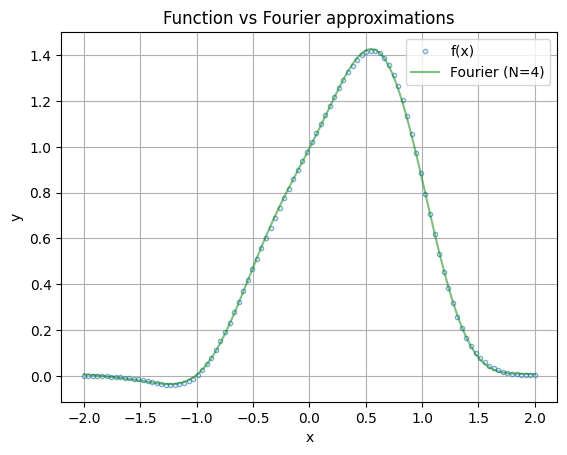

In [123]:
plt.figure()
plt.plot(xs, ys, linestyle='None', marker='o',markerfacecolor='none', markersize=3, label="f(x)", alpha=0.6)
plt.plot(xs, sx, 'g-', label=f"Fourier (N={N})", alpha=0.5)
plt.legend()
plt.title("Function vs Fourier approximations")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(1)

plt.savefig("f_fourier_approx.svg", format="svg", bbox_inches="tight")

plt.show()